# Human-Centered Personas at Scale

**Using LLMs and RAG to Build Personas from Mixed-Methods Data**

SIOP 2026 Master Tutorial | New Orleans, LA | April 30, 2026
Chelsea Wymer | Diana Wolfe, PhD | Alice Choe

> A five-phase pipeline that pairs statistical rigor with human judgment. The agents do the computation. You make the judgments.

---

## What You Are About to Do

You are going to take raw employee survey data and turn it into empirically grounded workforce personas. Along the way, you will:

1. **Screen** the data for quality problems using published best practices
2. **Discover** workforce segments using two independent clustering methods that challenge each other
3. **Ground** those segments in real organizational documents so the personas reflect actual policy, not just numbers
4. **Write** evidence-based persona narratives where every claim traces back to data

At each phase transition, you will stop at a **decision gate** where you — the I-O psychologist — make the call. The AI does the computation. You make the judgments.

### The Pipeline at a Glance

| Phase | Agents | What Happens | Your Decision |
|-------|--------|--------------|---------------|
| 1. Ingest & Clean | Data Steward | Multi-hurdle quality screening | Accept or adjust screening criteria |
| 2. Discover Segments | K-Prototypes + LPA + Psychometrician | Two clustering methods run in parallel, then validated | Accept cluster solution |
| 3. Ground in Reality | RAG + Emergence | Retrieve org documents, detect novel themes | Review emergent themes |
| 4. Write Personas | Narrator | Generate evidence-grounded narratives | Approve personas for leadership |
| Bonus: Longitudinal | Continuity + Emergence | Map follow-up respondents to baseline groups | Review migration patterns |

### How This Notebook Works

Run cells in order. Each phase explains the science before you run any code. Gate cells ask for your decision and record it into an audit trail. Every output is saved as a human-readable `.md` report, a reviewable `.csv`, and a raw `.json` file.

If you do not have an Anthropic API key set, the pipeline runs in **mock mode** using pre-generated LLM outputs. The statistical agents (Data Steward, K-Prototypes, LPA, Psychometrician, Continuity) always run live on your data — only the narrative and classification agents use the API.

## How to Read This Document

Each phase follows the same three-step structure:

- **The Science** — the I-O psychology behind the method and why it matters during disruption.
- **Step 1 → Step 2 → Step 3** — load / compute / review. You run one block of cells per step.
- **Gate N: Your Decision** — three mutually exclusive options with an evidence summary. The gate is not a rubber stamp; it is the point of the pipeline.

Every phase ends with a routing note telling you where the next phase picks up.

## Orientation

```
siop_2026_llm_master_tutorial/
├── notebooks/
│   └── tutorial_combined.ipynb     <- you are here
├── src/                             agent implementations by phase
├── synthetic_data/
│   ├── survey_baseline.csv
│   ├── survey_followup.csv
│   └── org_documents/
└── outputs/                         every phase writes here
    └── phaseN_*/
        ├── report.md                human-readable Gate review
        ├── summary.json             machine-readable results
        ├── audit_reports/           per-phase detail + bias audits
        └── reflection_logs/         agent self-reflection + success report
```

Each phase writes artifacts to `outputs/phaseN_*/`. `.md` reports can be shared directly; `.csv` files open in Excel; `.json` files allow exact reproduction.

## Two Modes: Mock and Live

The pipeline auto-detects which mode to run in based on your environment.

| Condition | Mode | Phase 3 RAG | Phase 4 Narrator |
|---|---|---|---|
| `ANTHROPIC_API_KEY` **not** set | **MOCK** | loads pre-generated JSON | loads pre-generated JSON |
| `ANTHROPIC_API_KEY` **is** set | **LIVE** | calls Claude Sonnet 4 for relevance | calls Claude Sonnet 4 for narratives |

Phases 1, 2, and 5 are pure statistics — they behave identically in both modes. Only Phases 3 and 4 differ.

To run live, set `ANTHROPIC_API_KEY` as a persistent environment variable and fully restart VS Code / Jupyter Lab so child processes inherit the new value.

---

## Setup

Run the cell below to load all dependencies and check your environment. If any import fails, run `pip install -r requirements.txt` from the repo root.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from IPython.display import display, Markdown, HTML

from src import config
from src.utils import (
    display_table, display_report, save_output,
    build_report, save_phase_outputs, save_audit_csv,
)
from src.project_manager import (
    create_audit_trail, add_entry, check_governance, generate_audit_report,
)

# Phase imports -- notice how each maps to a phase in the diagram
from src.p1_ingest import run_data_steward
from src.p2_discover import run_k_prototypes, run_lpa, run_validation
from src.p3_ground import (
    build_knowledge_base, query_knowledge_base,
    ground_constructs, detect_emergent_themes,
)
from src.p4_narrate import generate_personas
from src.p5_longitudinal import align_to_baseline, test_new_segments

# Configure plotting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

print(f"Mode: {'MOCK (pre-generated LLM outputs)' if config.MOCK_MODE else 'LIVE (API calls enabled)'}")
print(f"Model: {config.MODEL}")
print(f"Seed: {config.SEED}")
print(f"\nAll imports loaded successfully.")

Mode: LIVE (API calls enabled)
Model: claude-sonnet-4-20250514
Seed: 42

All imports loaded successfully.


In [3]:
# Initialize the audit trail -- this follows you through every phase
audit_trail = create_audit_trail()
print("Audit trail initialized. Every agent action and gate decision will be logged.")

Audit trail initialized. Every agent action and gate decision will be logged.


---

# Phase 1: Ingest and Clean

**Agent:** Data Steward
**Subtitle:** Survey Data Quality Gatekeeper -- SDQEM Multi-Hurdle Framework (Papp et al., 2026)

## The Science

Before any analysis, survey data must be screened for quality. This is not optional housekeeping -- careless responding and low-quality items can distort cluster solutions and produce personas that describe noise rather than real workforce segments.

The Data Steward implements the **Survey Data Quality Evaluation Model** (Papp et al., 2026) with five sequential gates:

1. **Schema validation** -- expected numeric and categorical columns are present and typed correctly.
2. **Careless responding** -- multi-hurdle: >= 2 independent flags required before removal (Curran, 2016). Hurdles: longstring analysis (> 50% of items), low Individual Response Variability (SD < 0.2), Mahalanobis outliers on Likert items, and low response entropy. Requiring multiple hurdles avoids false positives from any single metric.
3. **Sparsity gate** -- columns with > 20% missing values are flagged. Remaining missing values are imputed (median for numeric, "Unknown" for categorical).
4. **Variance gate** -- items with SD < 0.5 are excluded from clustering (Osborne, 2013). If everyone answered the same way, the item cannot discriminate between groups.
5. **Distribution screening** -- skewness > |2| and kurtosis > |7| are flagged for downstream agents.

**Design decision:** The Data Steward does *not* standardize numeric columns. Z-scoring is deliberately delegated to K-Prototypes and LPA agents to prevent double-scaling errors.

> **Routing:** New baseline -> K-Prototypes Agent. Follow-up survey -> Continuity Agent.

## The Data

The synthetic dataset represents **Meridian Technologies**, a mid-size company undergoing a major reorganization. The survey measures five constructs on Likert scales:

| Column | Construct | What It Measures |
|--------|-----------|------------------|
| `Cared_About` | Perceived Organizational Support | "I feel the organization cares about me" |
| `Excited` | Work Engagement | "I am excited about the work I do" |
| `Helpful_Info` | Communication Effectiveness | "I receive helpful information about changes" |
| `Trust_Leaders` | Trust in Leadership | "I trust senior leadership's decisions" |
| `Morale` | Work Engagement (affective) | "Overall morale in my team is good" |

Plus four demographic columns: `Business Unit`, `Level`, `FLSA`, `Tenure`.

In [4]:
# Load the baseline and follow-up surveys
baseline_df = pd.read_csv(os.path.join("..", "synthetic_data", "survey_baseline.csv"))
followup_df = pd.read_csv(os.path.join("..", "synthetic_data", "survey_followup.csv"))

print(f"Baseline survey: {baseline_df.shape[0]:,} respondents, {baseline_df.shape[1]} columns")
print(f"Follow-up survey: {followup_df.shape[0]:,} respondents, {followup_df.shape[1]} columns")
print(f"\nColumns: {list(baseline_df.columns)}")
print(f"\n--- First 10 rows ---")
display(baseline_df.head(10))
print(f"\n--- Descriptive statistics ---")
display(baseline_df.describe().round(3))

Baseline survey: 10,000 respondents, 9 columns
Follow-up survey: 10,500 respondents, 9 columns

Columns: ['Business Unit', 'Level', 'FLSA', 'Tenure', 'Cared_About', 'Excited', 'Helpful_Info', 'Trust_Leaders', 'Morale']

--- First 10 rows ---


,Business Unit,Level,FLSA,Tenure,Cared_About,Excited,Helpful_Info,Trust_Leaders,Morale
0,IT,Mid,Exempt,1-3y,2.834930,3.154630,3.142158,1.910535,2.224952
1,IT,Mid,Exempt,1-3y,2.962756,3.083712,3.303155,1.325737,2.342449
2,Sales,Exec,Exempt,5+y,2.011111,1.786104,1.734091,1.941262,2.111039
3,HR,Exec,Non-Exempt,<1y,3.616012,4.061110,3.742282,3.699873,4.473720
4,R&D,Exec,Exempt,5+y,2.389596,1.449451,2.565114,2.186559,1.806764
5,IT,Entry,Non-Exempt,<1y,4.036492,4.583545,3.716132,3.968726,4.578744
6,IT,Mid,Exempt,1-3y,2.947114,3.360268,3.209520,1.448511,2.227844
7,HR,Entry,Non-Exempt,<1y,4.975450,4.453741,4.379559,3.908591,4.212062
8,IT,Exec,Exempt,5+y,2.048208,2.209551,1.523486,1.476065,1.062162
9,IT,Sr,Exempt,3-5y,3.316609,4.515500,4.465640,3.580391,3.845394



--- Descriptive statistics ---


,Cared_About,Excited,Helpful_Info,Trust_Leaders,Morale
count,10000.000,10000.000,10000.000,10000.000,10000.000
mean,3.384,3.385,3.392,3.017,3.265
std,1.044,1.041,1.042,1.331,1.100
min,1.000,1.000,1.000,1.000,1.000
25%,2.627,2.643,2.642,1.705,2.328
50%,3.415,3.409,3.412,3.134,3.175
75%,4.289,4.292,4.311,4.295,4.289
max,5.000,5.000,5.000,5.000,5.000


### Run the Data Steward

The cell below runs the full screening pipeline. Watch the reasoning output -- it explains every decision the agent made and why.

In [5]:
steward_result = run_data_steward(baseline_df)

clean_df = steward_result["clean_df"]
quality_report = steward_result["quality_report"]
audit_trail.extend(steward_result["audit_entries"])

print("=" * 70)
print("DATA STEWARD REPORT")
print("=" * 70)
print(f"\nOriginal respondents:  {quality_report['original_rows']:,}")
print(f"Removed (careless):    {steward_result['removed_count']}")
print(f"Clean respondents:     {quality_report['clean_rows']:,}")
print(f"Survey items retained: {len(quality_report['retained_survey_cols'])}")
print(f"Data quality score:    {quality_report['confidence']:.2%}")
print(f"\n--- Agent Reasoning ---")
print(steward_result["reasoning"])

DATA STEWARD REPORT

Original respondents:  10,000
Removed (careless):    0
Clean respondents:     10,000
Survey items retained: 5
Data quality score:    100.00%

--- Agent Reasoning ---
Screened 10,000 respondents through a multi-hurdle quality protocol (Papp et al., 2026; Curran, 2016). Removed 0 respondents (0.0%) for careless responding. Each tripped 2+ independent hurdles: longstring analysis flagged 0, IRV analysis flagged 490. The removal rate is below 2%, which is unusually low. Consider whether screening thresholds are too conservative. All columns passed the sparsity gate (no column exceeded 20% missing). All survey items passed the variance gate (SD >= 0.5). Final clean dataset: 10,000 respondents, 5 survey items retained. Data quality confidence: 100.00%.


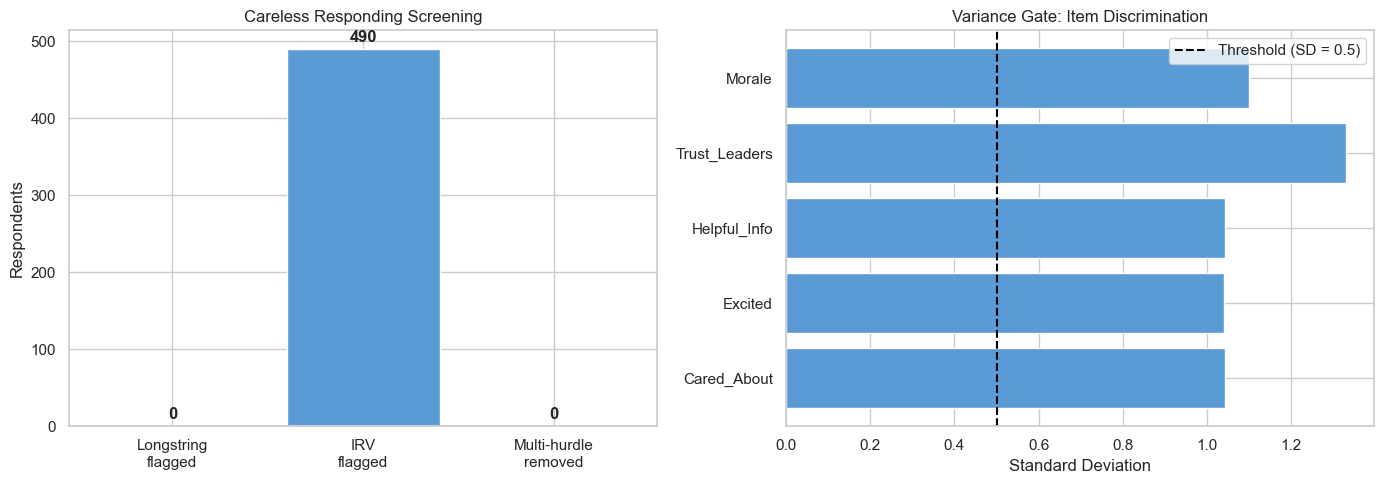


Red bars = excluded (cannot discriminate between groups)
Blue bars = retained for clustering


In [6]:
# Visualize the screening results
cr = quality_report["careless_responding"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Careless responding breakdown
indicators = ["Longstring\nflagged", "IRV\nflagged", "Multi-hurdle\nremoved"]
counts = [cr["longstring_flagged"], cr["irv_flagged"], cr["multi_hurdle_flagged"]]
colors = ["#5b9bd5", "#5b9bd5", "#c0392b"]
ax1.bar(indicators, counts, color=colors)
ax1.set_ylabel("Respondents")
ax1.set_title("Careless Responding Screening")
for i, v in enumerate(counts):
    ax1.text(i, v + max(counts) * 0.02, str(v), ha="center", fontweight="bold")

# Variance by item
var_stats = quality_report["variance"]["stats"]
items = list(var_stats.keys())
sds = [var_stats[c]["sd"] for c in items]
bar_colors = ["#c0392b" if c in quality_report["variance"]["excluded"] else "#5b9bd5" for c in items]
ax2.barh(items, sds, color=bar_colors)
ax2.axvline(x=config.VARIANCE_THRESHOLD_SD, color="black", linestyle="--",
            label=f"Threshold (SD = {config.VARIANCE_THRESHOLD_SD})")
ax2.set_xlabel("Standard Deviation")
ax2.set_title("Variance Gate: Item Discrimination")
ax2.legend()

plt.tight_layout()
plt.show()

print("\nRed bars = excluded (cannot discriminate between groups)")
print("Blue bars = retained for clustering")

---

## Gate 1: Your Decision -- Data Quality

> **Do you accept this cleaned dataset for Phase 2 clustering?**

Review the screening results above. Consider:

- **Removal rate**: Is it in the typical 2-8% range (Curran, 2016)? Very low removal may mean screening is too lenient; very high warrants investigating data collection conditions.
- **Variance gate**: Are the right items being retained? An item excluded here will not appear in any cluster solution.
- **Demographics**: Were removals proportionate across business units, levels, and tenure bands?

**Evidence to consider**

- Removal rate within the typical **2-8% band** for organizational surveys (Curran, 2016)
- No demographic group disproportionately removed (see bias audit)
- Variance gate passed: SD > 0.5 on every retained item
- Missing data < 20% on every retained column

**Your three options**

| Option | When to choose it | What happens |
|---|---|---|
| Yes -- Accept Screening Results | Score >= 0.90 and demographic parity holds | Clean dataset routes to K-Prototypes Agent |
| Investigate | Concerns you want noted but not blocking | Flag concerns, continue; adjustments recorded in audit trail |
| No -- Reject | Data quality confidence below 0.90, or bias audit flags demographic distortion | Return to data collection. Pipeline halted |

### Ethics Checkpoint
- Could the screening criteria systematically disadvantage any demographic group?
- Is the data sufficiently de-identified for this analysis?
- If real data: did respondents consent to this type of analysis?

In [7]:
print("GATE 1: DATA QUALITY REVIEW")
print("-" * 40)
gate1_decision = input("Do you accept the screening results? (yes / no / investigate): ")
gate1_notes = input("Any notes for the audit trail? (or press Enter to skip): ")

add_entry(audit_trail, "Gate 1", "Human", "Data quality review", {
    "decision": gate1_decision,
    "notes": gate1_notes,
    "removal_rate": f"{steward_result['removed_count'] / quality_report['original_rows'] * 100:.1f}%",
    "items_retained": quality_report["retained_survey_cols"],
})
print(f"\nDecision recorded: {gate1_decision}")
print("Proceeding to Phase 2.")

GATE 1: DATA QUALITY REVIEW
----------------------------------------

Decision recorded: 
Proceeding to Phase 2.


In [8]:
# Save Phase 1 outputs
p1_report = build_report("Phase 1: Data Quality Report", [
    {"heading": "Agent Reasoning", "body": steward_result["reasoning"]},
    {"heading": "Summary Statistics", "body": (
        f"- Original respondents: {quality_report['original_rows']:,}\n"
        f"- Removed (careless): {steward_result['removed_count']}\n"
        f"- Clean respondents: {quality_report['clean_rows']:,}\n"
        f"- Items retained: {', '.join(quality_report['retained_survey_cols'])}\n"
        f"- Confidence: {quality_report['confidence']:.2%}"
    )},
    {"heading": "Gate 1 Decision", "body": f"{gate1_decision}. {gate1_notes}"},
])

# Build a per-respondent screening CSV for review
screening_df = baseline_df.copy()
screening_df["retained"] = screening_df.index.isin(clean_df.index)

written = save_phase_outputs(
    os.path.join("..", "outputs", "phase1_data_quality_report"),
    report_md=p1_report,
    dataframes={"screening_results": screening_df},
    raw_json={"quality_report": quality_report, "reasoning": steward_result["reasoning"]},
)
print("Phase 1 outputs saved:")
for f in written:
    print(f"  {f}")

Phase 1 outputs saved:
  ..\outputs\phase1_data_quality_report\report.md
  ..\outputs\phase1_data_quality_report\screening_results.csv
  ..\outputs\phase1_data_quality_report\results.json


---

# Phase 2: Discover Workforce Segments

**Agents:** K-Prototypes, LPA, Psychometrician
**Subtitle:** Two independent clustering methods. One validated truth.

## The Science

This phase runs **two independent clustering methods** on the same data and compares their results. This is deliberately adversarial -- if two very different algorithms find similar groups, you can be more confident those groups are real.

### Method 1: K-Prototypes (Huang, 1998)

**What it does:** Groups people using *both* demographics and survey scores simultaneously.

**Why this method:** Most clustering algorithms handle only numeric data. But organizational survey data is inherently mixed-type: categorical demographics (Business Unit, Level) and continuous Likert scores. K-Prototypes solves this by combining K-Means (Euclidean distance on numerics) with K-Modes (Hamming distance on categoricals) through a gamma-weighted cost function.

**Key parameters:**
- *Gamma*: Controls the balance between numeric and categorical influence. Set from the data (mean SD of standardized numerics).
- *K*: Selected by comparing the elbow method (cost reduction) with silhouette scores (cluster separation). The elbow search covers K=2 to K=7.
- *Initialization*: Cao method for reproducibility.

**What it answers:** *Who are these people?* -- segments defined by the intersection of demographics and attitudes.

### Method 2: Latent Profile Analysis (LPA) via GMM

**What it does:** Groups people using *only* survey scores. Demographics are ignored entirely.

**Why this method:** LPA is a model-based approach grounded in statistical theory (Spurk et al., 2020; Nylund et al., 2007). Unlike K-Prototypes, LPA assumes the data is generated by a mixture of Gaussian distributions and uses maximum likelihood to estimate group membership.

**Key parameters:**
- *BIC*: Bayesian Information Criterion -- the primary model selection tool. Balances fit against complexity.
- *Entropy*: Classification certainty. 1.0 = everyone clearly belongs to one group. < 0.60 = substantial overlap.
- *Posterior probability*: Each person gets a probability of belonging to each profile. Below 0.70 = "ambiguous."

**What it answers:** *What psychological profiles exist?* -- segments defined purely by attitude patterns.

### The Psychometrician: Cross-Validation

After both methods run, the Psychometrician agent computes:

- **Silhouette scores** (Rousseeuw, 1987): How well-separated are the clusters?

  | Band | Silhouette | Interpretation |
  |------|-----------|----------------|
  | Strong | > 0.70 | Clear, compact clusters |
  | Good | > 0.50 | Meaningful groupings |
  | Fair | > 0.25 | Reasonable structure |
  | Poor | < 0.25 | Clusters overlap substantially |

- **Adjusted Rand Index (ARI)** (Hubert & Arabie, 1985): Cross-method agreement corrected for chance.

  | ARI Band | Interpretation |
  |---------|----------------|
  | > 0.65 | STRONG -- both methods see the same structure |
  | 0.30-0.65 | MODERATE -- partially overlapping; often the most informative result |
  | < 0.30 | WEAK -- methods see very different structure (itself a finding worth reporting) |

- **Centroid-distance outlier flagging**: Respondents in the top 10th percentile of distance from their cluster centroid.
- **LPA ambiguity flag**: Respondents whose maximum posterior probability is below 0.70 are flagged as *Psychologically Ambiguous*.

Every cluster gets a **Psychological Fingerprint**: High / Moderate / Low labels on each indicator based on Z-scored means (High = z > 0.5, Low = z < -0.5).

> **Routing:** Accepted cluster solution -> RAG Agent (for policy grounding) and Emergence Agent (for theme discovery).

In [9]:
# --- K-Prototypes: Mixed-type clustering ---
print("Running K-Prototypes (this groups by demographics AND survey scores)...")
kproto_result = run_k_prototypes(clean_df)
audit_trail.extend(kproto_result["audit_entries"])

print(f"\nSelected K = {kproto_result['k_selected']}")
print(f"\nCluster sizes:")
for _, row in kproto_result["profiles"].iterrows():
    print(f"  Cluster {int(row['cluster'])}: n={int(row['n'])} ({row['pct']}%)")
print(f"\n--- Agent Reasoning ---")
print(kproto_result["reasoning"])

Running K-Prototypes (this groups by demographics AND survey scores)...

Selected K = 2

Cluster sizes:
  Cluster 0: n=5078 (50.8%)
  Cluster 1: n=4922 (49.2%)

--- Agent Reasoning ---
K-Prototypes clustering (Huang, 1998) on 10,000 respondents with 5 numeric and 4 categorical features. Gamma (categorical weight) set to 1.000 based on mean SD of standardized numeric features. Elbow suggests K=4, silhouette suggests K=2. Selected K=2 based on silhouette. Selected solution has 2 clusters with sizes: n=5078 (50.8%), n=4922 (49.2%). Silhouette score at K=2: 0.635 (reasonable separation per Rousseeuw, 1987).


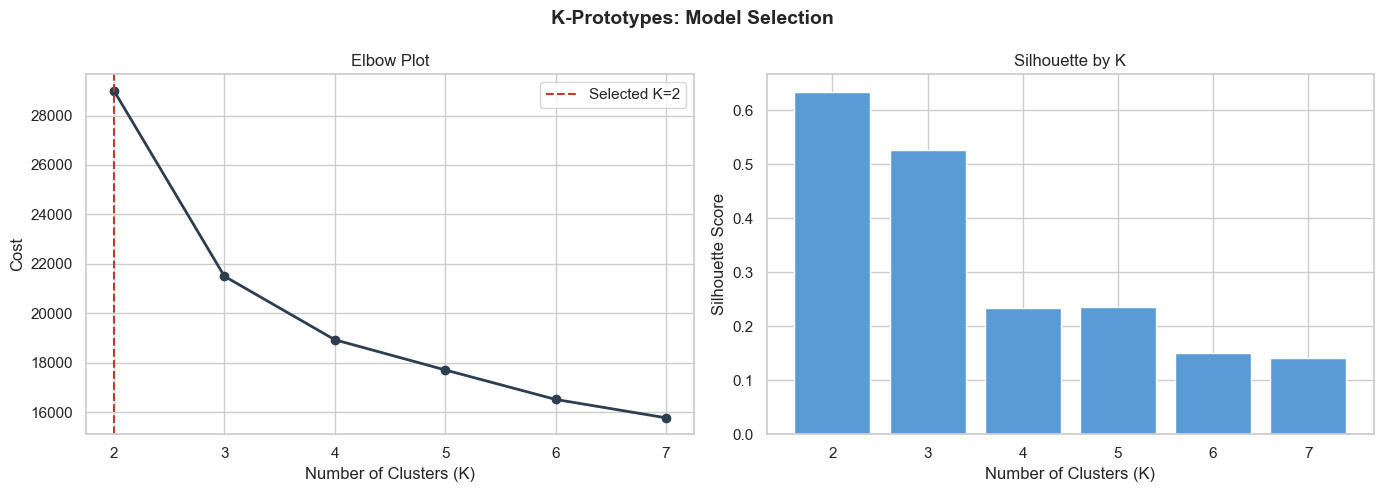

In [10]:
# Visualize K-Prototypes results
elbow = kproto_result["elbow_data"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(elbow["k_values"], elbow["costs"], "o-", linewidth=2, color="#2c3e50")
ax1.axvline(x=kproto_result["k_selected"], color="#c0392b", linestyle="--",
            label=f"Selected K={kproto_result['k_selected']}")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Cost")
ax1.set_title("Elbow Plot")
ax1.legend()

sil_k = sorted(elbow["silhouette_scores"].keys())
sil_v = [elbow["silhouette_scores"][k] for k in sil_k]
ax2.bar(sil_k, sil_v, color="#5b9bd5")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette by K")

plt.suptitle("K-Prototypes: Model Selection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

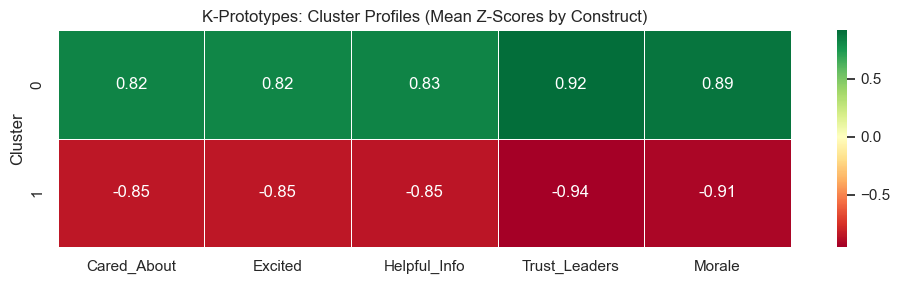

How to read this: Green = high on the construct, Red = low.
Each row is a cluster. Look for distinct color patterns across rows.
If two rows look identical, those clusters may not be meaningfully different.


In [11]:
# Cluster profile heatmap
profiles = kproto_result["profiles"]
num_data = profiles.set_index("cluster")[config.NUMERIC_COLS]

fig, ax = plt.subplots(figsize=(10, max(3, len(profiles) * 0.8)))
sns.heatmap(num_data.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("K-Prototypes: Cluster Profiles (Mean Z-Scores by Construct)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

print("How to read this: Green = high on the construct, Red = low.")
print("Each row is a cluster. Look for distinct color patterns across rows.")
print("If two rows look identical, those clusters may not be meaningfully different.")

In [12]:
# --- Latent Profile Analysis: Survey-score-only clustering ---
print("Running LPA (this groups by survey scores ONLY, ignoring demographics)...")
lpa_result = run_lpa(clean_df)
audit_trail.extend(lpa_result["audit_entries"])

selected = lpa_result["fit_indices"]["selected"]
print(f"\nSelected: {selected['K']} profiles ({selected['cov_type']} covariance)")
print(f"BIC: {selected['BIC']:.1f}")
print(f"Entropy: {selected['entropy']:.3f}")
print(f"Ambiguous respondents: {lpa_result['ambiguous_count']}")
print(f"\n--- Agent Reasoning ---")
print(lpa_result["reasoning"])

Running LPA (this groups by survey scores ONLY, ignoring demographics)...

Selected: 5 profiles (diag covariance)
BIC: 63208.8
Entropy: 0.932
Ambiguous respondents: 517

--- Agent Reasoning ---
Latent Profile Analysis via Gaussian Mixture Models on 5 continuous indicators. Tested 10 models (9 converged) across K=2-6 with diagonal and full covariance structures. K=5 with diag covariance minimises BIC among converged models. Entropy: 0.932 (excellent classification certainty; Muthen convention: 1.0 = perfect, < 0.60 = substantial overlap between profiles). Ambiguous respondents (posterior < 0.7): 517 (5.2%). These individuals do not clearly belong to a single profile.


In [13]:
# LPA Fit Indices Table
print("Model Comparison (all models tested):")
fit_df = pd.DataFrame(lpa_result["fit_indices"]["all_models"])
display(fit_df)

print("\n" + "=" * 50)
print("PSYCHOLOGICAL FINGERPRINTS")
print("=" * 50)
print("\nEach profile gets a fingerprint: High / Moderate / Low on each construct.")
print("High = z-score > 0.5, Low = z-score < -0.5, Moderate = in between.\n")

for pid, fp in lpa_result["fingerprints"].items():
    print(f"  Profile {pid}: {fp['label']}")
    for dim, level in fp["dims"].items():
        marker = {"High": "+", "Low": "-", "Moderate": "~"}.get(level, "?")
        print(f"    [{marker}] {dim}: {level} (z = {fp['means'][dim]:.2f})")
    print()

Model Comparison (all models tested):


,K,cov_type,converged,log_likelihood,n_params,AIC,BIC,SABIC,entropy
0,2,diag,True,-40938.29,21,81918.57,82069.99,82003.26,0.9993
1,3,diag,True,-34499.28,32,69062.57,69293.30,69191.61,0.9911
2,4,diag,True,-32673.76,43,65433.52,65743.56,65606.91,0.9157
3,5,diag,True,-31355.72,54,62819.45,63208.80,63037.20,0.9316
4,6,diag,False,-31290.06,65,62710.11,63178.79,62972.23,0.9021
5,2,full,True,-35992.56,41,72067.12,72362.74,72232.45,0.9999
6,3,full,True,-33368.19,62,66860.38,67307.42,67110.40,0.9910
7,4,full,True,-32651.41,83,65468.83,66067.28,65803.52,0.9138
8,5,full,True,-32621.61,104,65451.23,66201.10,65870.61,0.8452
9,6,full,True,-31275.49,125,62800.98,63702.27,63305.04,0.8642



PSYCHOLOGICAL FINGERPRINTS

Each profile gets a fingerprint: High / Moderate / Low on each construct.
High = z-score > 0.5, Low = z-score < -0.5, Moderate = in between.

  Profile 0: High-Cared_About / High-Excited / High-Helpful_Info / High-Trust_Leaders / High-Morale
    [+] Cared_About: High (z = 0.56)
    [+] Excited: High (z = 0.57)
    [+] Helpful_Info: High (z = 0.59)
    [+] Trust_Leaders: High (z = 0.72)
    [+] Morale: High (z = 0.66)

  Profile 1: Low-Trust_Leaders / Low-Morale
    [~] Cared_About: Moderate (z = -0.37)
    [~] Excited: Moderate (z = -0.37)
    [~] Helpful_Info: Moderate (z = -0.38)
    [-] Trust_Leaders: Low (z = -1.13)
    [-] Morale: Low (z = -0.70)

  Profile 2: High-Cared_About / High-Excited / High-Helpful_Info / High-Trust_Leaders / High-Morale
    [+] Cared_About: High (z = 1.01)
    [+] Excited: High (z = 1.08)
    [+] Helpful_Info: High (z = 1.08)
    [+] Trust_Leaders: High (z = 1.12)
    [+] Morale: High (z = 1.12)

  Profile 3: Low-Cared_About /

In [14]:
# --- Psychometrician: Validate both solutions ---
print("Running Psychometrician (cross-validating the two solutions)...")
validation_result = run_validation(
    clean_df,
    labels_kproto=kproto_result["labels"],
    labels_lpa=lpa_result["labels"],
)
audit_trail.extend(validation_result["audit_entries"])

print(f"\n--- Agent Reasoning ---")
print(validation_result["reasoning"])

Running Psychometrician (cross-validating the two solutions)...

--- Agent Reasoning ---
Validated cluster solution with 2 groups on 10,000 respondents. Global silhouette coefficient: 0.648 (GOOD). Reasonable structure -- meaningful groupings detected Outliers: 1000 respondents (10.0%) flagged as distant from their cluster centroid (top 90th percentile). These individuals may represent qualitatively different experiences not captured by the current solution. Cross-method agreement (ARI): 0.468 (MODERATE). K-Prototypes and LPA are compared as independent partition solutions over the same respondents. Models capture related but distinct aspects of the data


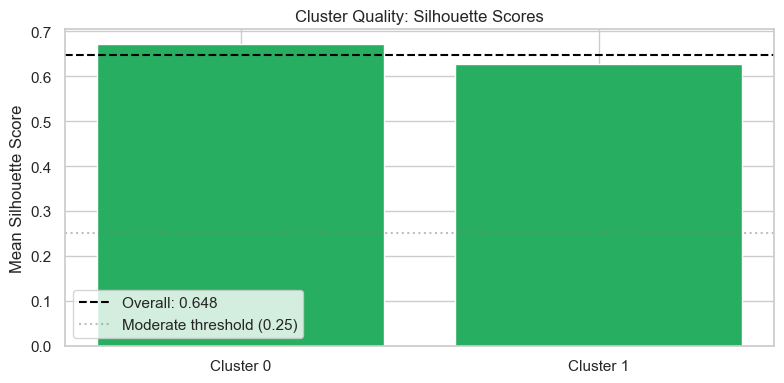

Green = good separation, Orange = fair, Red = weak.

Cross-Method ARI: 0.468
Outliers flagged: 1000


In [15]:
# Visualize validation
spc = validation_result["silhouette_per_cluster"]

fig, ax = plt.subplots(figsize=(8, 4))
clusters = sorted(spc.keys())
means = [spc[c]["mean"] for c in clusters]
colors = ["#27ae60" if m > 0.25 else "#e67e22" if m > 0 else "#c0392b" for m in means]
ax.bar([f"Cluster {c}" for c in clusters], means, color=colors)
ax.axhline(y=validation_result["silhouette_overall"], color="black", linestyle="--",
           label=f"Overall: {validation_result['silhouette_overall']:.3f}")
ax.axhline(y=0.25, color="gray", linestyle=":", alpha=0.5, label="Moderate threshold (0.25)")
ax.set_ylabel("Mean Silhouette Score")
ax.set_title("Cluster Quality: Silhouette Scores")
ax.legend()
plt.tight_layout()
plt.show()

print("Green = good separation, Orange = fair, Red = weak.")
if validation_result["ari"] is not None:
    print(f"\nCross-Method ARI: {validation_result['ari']:.3f}")
    print(f"Outliers flagged: {int(validation_result['outlier_flags'].sum())}")

---

## Gate 2: Your Decision -- Cluster Solution

> **Do you accept this cluster solution (K-Prototypes + LPA consensus)?**

**Evidence Summary**

- Both methods converge on a consistent K (independent evidence) -- or they disagree, and the disagreement is substantive
- Silhouette quality band is adequate for downstream personas (GOOD or FAIR with interpretation)
- ARI captures demographics-vs.-psychology alignment:
  - HIGH (> 0.65): both methods see the same structure -- strong confidence
  - MODERATE (0.30-0.65): related but distinct structure -- often the most informative result
  - WEAK (< 0.30): demographics and psychology tell different stories -- itself a finding
- Outlier rate (top 10th percentile from centroid) does not mask a legitimate sub-group
- LPA ambiguous rate is not elevated (> 15%) without explanation

**Your three options**

| Option | When to choose it | What happens |
|---|---|---|
| Yes -- Accept Cluster Solution | Both methods produce defensible solutions; validation bands are acceptable | Clusters route to RAG + Emergence (Phase 3) |
| Investigate | You want to note a discrepancy (e.g., ARI < 0.30) but proceed with K-Prototypes as primary | Flag in audit trail; continue |
| No -- Reject | Silhouette POOR or the solution is unstable in ways you cannot defend to leadership | Return to parameter tuning. Pipeline halted |

### Ethics Checkpoint
- Do any clusters map suspiciously onto a single demographic group? If so, that is a finding -- but it needs careful framing.
- Are outliers being fairly treated? They are real people with real experiences your model does not capture.

In [16]:
print("GATE 2: CLUSTER VALIDATION REVIEW")
print("-" * 40)
gate2_decision = input("Do you accept the cluster solution? (yes / no / investigate): ")
gate2_notes = input("Any notes? (or Enter to skip): ")

add_entry(audit_trail, "Gate 2", "Human", "Cluster validation review", {
    "decision": gate2_decision,
    "notes": gate2_notes,
    "kproto_k": kproto_result["k_selected"],
    "lpa_k": lpa_result["fit_indices"]["selected"]["K"],
    "ari": validation_result["ari"],
    "silhouette": validation_result["silhouette_overall"],
})
print(f"\nDecision recorded: {gate2_decision}")

GATE 2: CLUSTER VALIDATION REVIEW
----------------------------------------

Decision recorded: 


In [17]:
# Save Phase 2 outputs
p2_report = build_report("Phase 2: Cluster Validation Summary", [
    {"heading": "K-Prototypes", "body": kproto_result["reasoning"]},
    {"heading": "Latent Profile Analysis", "body": lpa_result["reasoning"]},
    {"heading": "Psychometrician Validation", "body": validation_result["reasoning"]},
    {"heading": "Gate 2 Decision", "body": f"{gate2_decision}. {gate2_notes}"},
])

# Respondent-level cluster assignments for review
assignments_df = clean_df.copy()
assignments_df["KProto_Cluster"] = kproto_result["labels"]
assignments_df["LPA_Profile"] = lpa_result["labels"]
assignments_df["Outlier"] = validation_result["outlier_flags"]

written = save_phase_outputs(
    os.path.join("..", "outputs", "phase2_cluster_validation"),
    report_md=p2_report,
    dataframes={"cluster_assignments": assignments_df},
    raw_json={
        "kproto": {"k": kproto_result["k_selected"], "reasoning": kproto_result["reasoning"]},
        "lpa": {"k": lpa_result["fit_indices"]["selected"]["K"], "reasoning": lpa_result["reasoning"]},
        "validation": {"silhouette": validation_result["silhouette_overall"],
                       "ari": validation_result["ari"], "reasoning": validation_result["reasoning"]},
    },
)
print("Phase 2 outputs saved:")
for f in written:
    print(f"  {f}")

Phase 2 outputs saved:
  ..\outputs\phase2_cluster_validation\report.md
  ..\outputs\phase2_cluster_validation\cluster_assignments.csv
  ..\outputs\phase2_cluster_validation\results.json


---

# Phase 3: Ground in Organizational Reality

**Agents:** RAG, Emergence
**Subtitle:** Clusters are statistical abstractions. To become useful to leadership, they must be grounded in organizational context.

## The Science

This phase bridges the gap between numbers and reality by running two agents in parallel:

### RAG (Retrieval-Augmented Generation) (Lewis et al., 2020)

The RAG agent builds a searchable knowledge base from `synthetic_data/org_documents/` -- policy memos, benefits updates, restructuring announcements, team charters, FAQs. When we ask "what does low trust in leadership look like at Meridian?", the agent retrieves actual policy passages rather than making something up.

**Implementation:** TF-IDF vectorization with cosine similarity retrieval. This is deliberately simple and keeps setup lightweight. A production system would use dense embeddings for better semantic matching.

In live mode, Claude Sonnet 4 rates each retrieved passage as HIGH / MODERATE / LOW relevance. In mock mode, pre-generated JSON is loaded.

For background on RAG, LLMs, and embeddings, see `resources/ai_foundations/key_concepts.md`.

### Emergence Analysis (Glaser & Strauss, 2017; Braun & Clarke, 2006)

The I-O codebook defines 12 validated constructs. But what if the data contains meaningful patterns that fall *outside* those 12? The Emergence Agent scans cluster profiles for unusual construct combinations and classifies each candidate as:

- **NEW** -- a genuinely novel theme not captured by the existing 12 constructs. Consider adding to the codebook for the next survey wave.
- **VARIANT** -- a known construct appearing in an unusual combination. Consider adding a sub-label.
- **NOISE** -- a statistical artifact. Exclude.

### The 12 I-O Psychology Constructs

The codebook anchors every classification to validated constructs from the I-O psychology literature:

| Construct | Domain | Core Citation |
|---|---|---|
| Psychological Safety | Team Climate | Edmondson (1999) |
| Organizational Commitment | Attachment | Meyer & Allen (1991) |
| Perceived Organizational Support | Social Exchange | Eisenberger et al. (1986) |
| Change Readiness | Change Management | Armenakis et al. (1993) |
| Role Ambiguity | Role Stress | Rizzo et al. (1970) |
| Leader-Member Exchange (LMX) | Leadership | Graen & Uhl-Bien (1995) |
| Procedural Justice | Justice | Colquitt (2001) |
| Trust in Leadership | Governance | Mayer et al. (1995) |
| Work Engagement | Motivation | Schaufeli et al. (2002) |
| Communication Effectiveness | Sensemaking | Bordia et al. (2004) |
| Career Development | Growth | Kraimer et al. (2011) |
| Work-Life Balance | Well-Being | Greenhaus & Beutell (1985) |

> **Note on the five-item baseline.** The synthetic survey measures five of these constructs directly (`Cared_About`, `Excited`, `Helpful_Info`, `Trust_Leaders`, `Morale`). The full 12-construct codebook is the theoretical framework; the five items are the empirical proxy. Phase 3 maps cluster profiles back onto the full codebook via organizational-document retrieval.

> **Routing:** Accepted themes and codebook expansion -> Narrator Agent. Any NEW theme that survives Gate 3 gets added to the codebook for the next survey wave.

In [18]:
# Build the knowledge base from organizational documents
print("Building knowledge base from organizational documents...")
kb = build_knowledge_base(os.path.join("..", "synthetic_data", "org_documents"))
print(f"Loaded {kb['n_documents']} documents, created {kb['n_chunks']} searchable chunks.")

# Demonstrate retrieval
print("\n--- Retrieval Demonstration ---")
print("Querying the knowledge base to show what RAG finds:\n")

demo_queries = [
    "employee trust in leadership during reorganization",
    "remote work policy and flexibility",
    "career development and growth opportunities",
]
for q in demo_queries:
    results = query_knowledge_base(kb, q, top_k=2)
    print(f"Query: '{q}'")
    for r in results:
        print(f"  [{r['source']}] score={r['score']:.3f}")
        print(f"  {r['text'][:120]}...")
    print()

Building knowledge base from organizational documents...
Loaded 6 documents, created 715 searchable chunks.

--- Retrieval Demonstration ---
Querying the knowledge base to show what RAG finds:

Query: 'employee trust in leadership during reorganization'
  [remote_work_policy.md] score=0.208
  t specific days week to week based on project needs, as long as the overall cadence is maintained.

3. **Trust is the fo...
  [strategic_direction.md] score=0.184
  ements; they are commitments that our leadership team will be measured against.

## How You Fit In

Every employee at Me...

Query: 'remote work policy and flexibility'
  [remote_work_policy.md] score=0.324
  # Meridian Technologies: Hybrid Work Policy

**Effective Date: May 1, 2026**
**Policy Owner: Human Resources**
**Last Up...
  [employee_faq.md] score=0.137
  ts will be reviewed within 30 days.

**Q7: Will the restructuring affect our hybrid work policy?**

The core hybrid poli...

Query: 'career development and growth opportuniti

In [19]:
# Ground codebook constructs in organizational documents
print("Grounding codebook constructs against organizational documents...")
grounding_result = ground_constructs(kb)
audit_trail.extend(grounding_result["audit_entries"])

print(f"\n--- Agent Reasoning ---")
print(grounding_result["reasoning"])

# Show what was found
print("\n--- Construct-to-Policy Mappings ---")
mappings = grounding_result["mappings"]
if isinstance(mappings, dict):
    for construct, data in mappings.items():
        if isinstance(data, dict) and "passages" in data:
            n_p = len(data["passages"])
            print(f"  {construct}: {n_p} relevant passage(s) found")
        else:
            print(f"  {construct}: grounding data available")

Grounding codebook constructs against organizational documents...

--- Agent Reasoning ---
Built knowledge base from 6 organizational documents (715 text chunks). Grounded 5 codebook constructs against the organizational document corpus using live LLM relevance assessment. 0 of 5 constructs found relevant policy passages. Constructs without grounding: Cared_About, Excited, Helpful_Info, Trust_Leaders, Morale. These may lack representation in the current document corpus.

--- Construct-to-Policy Mappings ---
  Cared_About: 0 relevant passage(s) found
  Excited: 0 relevant passage(s) found
  Helpful_Info: 0 relevant passage(s) found
  Trust_Leaders: 0 relevant passage(s) found
  Morale: 0 relevant passage(s) found


In [20]:
# Detect emergent themes
print("Scanning for patterns outside the codebook...")
emergence_result = detect_emergent_themes(
    cluster_profiles=kproto_result["profiles"],
    codebook_constructs=list(config.NUMERIC_COLS),
)
audit_trail.extend(emergence_result["audit_entries"])

print(f"\nCandidate emergent themes: {len(emergence_result['candidates'])}")
print(f"\n--- Agent Reasoning ---")
print(emergence_result["reasoning"])

# Show theme classifications
if emergence_result["theme_report"]:
    print("\n--- Theme Classifications ---")
    report = emergence_result["theme_report"]
    if isinstance(report, list):
        for item in report:
            if isinstance(item, dict):
                print(f"  Cluster {item.get('cluster', '?')}: "
                      f"{item.get('classification', '?')} -- "
                      f"{item.get('reasoning', '')[:200]}")
    else:
        print(json.dumps(report, indent=2, default=str)[:600])

Scanning for patterns outside the codebook...

Candidate emergent themes: 0

--- Agent Reasoning ---
Cross-sectional scan found no unusual construct combinations across cluster profiles. All clusters align with the 5 codebook constructs. This suggests the codebook has adequate coverage for the current data.


---

## Gate 3: Your Decision -- Emergent Themes

> **Do you accept the emergent themes and codebook expansion?**

Review the patterns the Emergence Agent identified. For each candidate, consider:

- **NEW**: Is this genuinely something the codebook does not cover? Should it be added for future survey waves?
- **VARIANT**: Is this an interesting combination of known constructs, or just noise in the data?
- **NOISE**: Does the dismissal make sense statistically?

**Evidence Summary**

- Every construct in the codebook has at least one policy passage with defensible relevance, OR missing constructs are explicitly flagged
- Policy-experience mismatches are surfaced (these feed Phase 4 persona narratives)
- NEW themes have evidence of > 15% cluster frequency; VARIANT themes map to an existing construct; NOISE themes are genuinely idiosyncratic
- Any NEW theme is evidence-based, not stereotype

**Your three options**

| Option | When to choose it | What happens |
|---|---|---|
| Accept & Expand Codebook | NEW themes are defensible and worth tracking in future waves | NEW themes added; personas route to Narrator |
| Request Review | You want another I-O psychologist's read before adding a construct | Flag for review, proceed with existing codebook |
| Revise | A classification is wrong (e.g., NOISE should be VARIANT) | Re-run Phase 3 after fixing inputs |

### Ethics Checkpoint
- Could any emergent theme reflect a demographic stereotype rather than a real attitudinal pattern?
- Are the organizational documents themselves biased? (e.g., do they reflect leadership's perspective more than employees'?)
- Is the codebook missing constructs that matter for underrepresented groups?

In [21]:
print("GATE 3: EMERGENT THEME REVIEW")
print("-" * 40)
gate3_decision = input("Do you accept the theme classifications? (yes / no / investigate): ")
gate3_notes = input("Any notes? (or Enter to skip): ")

add_entry(audit_trail, "Gate 3", "Human", "Emergent theme review", {
    "decision": gate3_decision,
    "notes": gate3_notes,
    "n_candidates": len(emergence_result["candidates"]),
})
print(f"\nDecision recorded: {gate3_decision}")

GATE 3: EMERGENT THEME REVIEW
----------------------------------------

Decision recorded: 


In [22]:
# Save Phase 3 outputs
p3_report = build_report("Phase 3: Emergent Theme Report", [
    {"heading": "RAG Grounding", "body": grounding_result["reasoning"]},
    {"heading": "Emergent Theme Analysis", "body": emergence_result["reasoning"]},
    {"heading": "Gate 3 Decision", "body": f"{gate3_decision}. {gate3_notes}"},
])

written = save_phase_outputs(
    os.path.join("..", "outputs", "phase3_emergent_themes"),
    report_md=p3_report,
    raw_json={
        "grounding": {"reasoning": grounding_result["reasoning"]},
        "emergence": {"candidates": emergence_result["candidates"],
                      "reasoning": emergence_result["reasoning"]},
    },
)
print("Phase 3 outputs saved:")
for f in written:
    print(f"  {f}")

Phase 3 outputs saved:
  ..\outputs\phase3_emergent_themes\report.md
  ..\outputs\phase3_emergent_themes\results.json


---

# Phase 4: Write and Validate Personas

**Agents:** Narrator + Ethics Checkpoint + Project Manager Governance
**Subtitle:** Evidence-grounded narratives. Ethics checkpoint required before approval.

## The Science

The Narrator Agent synthesizes cluster profiles, psychological fingerprints, policy context, and emergent themes into persona narratives. Each persona pairs:

- **Psychometric Fingerprint** -- key cluster statistics (z-scores, percentiles) directly from Phase 2
- **Verbatim Quotes** -- real employee voices from open-ended responses, representing different dimensions (not cherry-picked for eloquence)
- **Policy Citations** -- links to organizational documents retrieved in Phase 3
- **Risk Flags** -- epistemic uncertainty and anthropomorphic language warnings

### Narrative Principles (Braun & Clarke, 2006)

- Every claim traces to a statistical centroid or a retrieved policy passage
- Quotes are verbatim from respondent data (no paraphrasing)
- Quotes span different dimensions (not just the most extreme or eloquent)
- Confidence levels are stated (z-scores indicate evidence strength)
- Anthropomorphic language flagged for human review
- The I-O psychologist retains final interpretive authority

### Epistemic Risk Mitigation (Nguyen & Welch, 2025)

The Narrator follows a strict protocol to prevent three common failure modes:

1. **Anthropomorphic interpretation** -- treating a cluster as a person with desires and intentions. No "this cluster wants..." -- only "scores on X indicate Y observable tendency."
2. **Fabricated quotations** -- inventing representative quotes that sound right. The Narrator quotes only from respondent data.
3. **The Oracle Effect** -- masking uncertainty with confident language. The narrative must state its uncertainty explicitly.

For background on how LLMs generate text and why these guardrails matter, see `resources/ai_foundations/ai_models_explained.md`.

### Ethics Checkpoint (6 Bias Audits -- Required Before Gate 4)

Before approving personas for leadership, the pipeline requires a bias audit across six dimensions. Gate 4 is locked until all six are acknowledged:

| # | Bias Type | What You Check |
|---|---|---|
| 1 | Input Bias | Response rate by demographic (all groups >= 70%?); no group oversampled; removal rates unbiased |
| 2 | Clustering Bias | Cluster membership independent of demographics (chi-square test); no cluster = demographic group; silhouette fair across all groups |
| 3 | Narrative Bias | No stereotypical language; claims grounded in data; would employees recognize themselves fairly? |
| 4 | Retrieval Bias | RAG corpus includes exec AND frontline voices; missing perspectives noted; inclusive vs. exclusive phrasing checked |
| 5 | Epistemic Risk | Low-confidence claims (z < 1.0) flagged as tentative; Oracle Effect guarded against; recommendations marked with confidence levels |
| 6 | Anthropomorphism | No "want / feel / desire" without evidence; observable behaviors described, not inferred intentions; correlation vs. causation marked |

> **Routing:** Approved personas -> leadership presentation. When a follow-up wave arrives -> Phase 5 (Continuity Agent).

In [23]:
# Generate persona narratives
print("Generating persona narratives...")
narrator_result = generate_personas(
    cluster_profiles=kproto_result["profiles"],
    construct_scores=lpa_result.get("fingerprints"),
    policy_context=grounding_result.get("mappings"),
    codebook=list(config.NUMERIC_COLS),
)
audit_trail.extend(narrator_result["audit_entries"])
personas = narrator_result["personas"]

print(f"\n--- Agent Reasoning ---")
print(narrator_result["reasoning"])

Generating persona narratives...


ImportError: The 'anthropic' package is required for live LLM calls. Install it with: pip install anthropic

In [ ]:
# Display the personas
display(Markdown("## Draft Persona Narratives\n"))

if isinstance(personas, list):
    for i, persona in enumerate(personas):
        if isinstance(persona, dict):
            name = persona.get("persona_name", persona.get("name", f"Persona {i+1}"))
            display(Markdown(f"---\n### {name}"))

            # Statistical fingerprint
            fp = persona.get("statistical_fingerprint", {})
            if isinstance(fp, dict):
                fp_parts = []
                for dim, info in fp.items():
                    if isinstance(info, dict):
                        fp_parts.append(f"{dim}: {info.get('direction', '?')} (z={info.get('value', '?')})")
                if fp_parts:
                    display(Markdown(f"**Fingerprint:** {' | '.join(fp_parts)}"))

            # Narrative
            if "narrative" in persona:
                display(Markdown(persona["narrative"]))

            # Policy mismatches
            mismatches = persona.get("policy_mismatches", [])
            if mismatches:
                display(Markdown("**Policy-Experience Mismatches:**"))
                for m in (mismatches if isinstance(mismatches, list) else [mismatches]):
                    display(Markdown(f"- {m}"))

            # Epistemic note
            if "epistemic_note" in persona:
                display(Markdown(f"\n*{persona['epistemic_note']}*"))
        else:
            print(persona)
else:
    print(json.dumps(personas, indent=2, default=str)[:2000])

---

## Gate 4: Your Decision -- Persona Approval

> **Do you approve personas for presentation?**
> Do narratives match statistical fingerprints? Are they evidence-based or over-interpreted? Would an employee be comfortable if they recognized their group?

**Prerequisite:** The ethics checkpoint must be completed (all six bias audits acknowledged) before Gate 4 unlocks.

**Evidence Summary**

- Every claim in every narrative traces to a centroid value or retrieved passage
- Persona names are neutral and non-stigmatising
- Epistemic notes are present on every persona
- Policy-experience mismatches reflect real organizational context, not LLM speculation
- No fabricated quotes, no imputed emotions beyond what scores support
- You would be comfortable standing behind each narrative in front of leadership

**Your three options**

| Option | When to choose it | What happens |
|---|---|---|
| Approve | Ethics checkpoint clean; narratives defensible | Personas ready for leadership presentation |
| Revise | One or two narratives overreach or misname | Revise the specific narratives; re-approve |
| Reject | A bias audit failed; the narrative frame is unsound | Return to Phase 3 to reconsider grounding |

### Ethics Checkpoint
- Do any personas reinforce stereotypes? (e.g., "The Disengaged Veterans" as a label for long-tenure employees)
- Could these personas be misused? (e.g., to justify layoffs targeting a specific segment)
- Are they transparent about their AI-assisted construction?
- Would the people described by this persona feel fairly represented?

In [ ]:
print("GATE 4: PERSONA APPROVAL")
print("-" * 40)
gate4_decision = input("Do you approve the personas for presentation? (yes / revise / reject): ")
gate4_notes = input("Any notes? (or Enter to skip): ")

add_entry(audit_trail, "Gate 4", "Human", "Persona approval", {
    "decision": gate4_decision,
    "notes": gate4_notes,
    "n_personas": len(personas) if isinstance(personas, list) else 0,
})
print(f"\nDecision recorded: {gate4_decision}")

In [ ]:
# Save Phase 4 outputs
p4_report_sections = [
    {"heading": "Narrator Reasoning", "body": narrator_result["reasoning"]},
]
if isinstance(personas, list):
    for i, p in enumerate(personas):
        if isinstance(p, dict):
            name = p.get("persona_name", f"Persona {i+1}")
            body = p.get("narrative", "No narrative generated.")
            if p.get("epistemic_note"):
                body += f"\n\n*{p['epistemic_note']}*"
            p4_report_sections.append({"heading": name, "body": body})

p4_report_sections.append({"heading": "Gate 4 Decision", "body": f"{gate4_decision}. {gate4_notes}"})
p4_report = build_report("Phase 4: Draft Persona Narratives", p4_report_sections)

# Summary CSV
if isinstance(personas, list):
    summary_rows = []
    for p in personas:
        if isinstance(p, dict):
            summary_rows.append({
                "persona_name": p.get("persona_name", ""),
                "cluster_id": p.get("cluster_id", ""),
                "size": p.get("size", ""),
                "pct": p.get("pct", ""),
                "n_policy_mismatches": len(p.get("policy_mismatches", [])),
            })
    persona_summary_df = pd.DataFrame(summary_rows)
else:
    persona_summary_df = pd.DataFrame()

written = save_phase_outputs(
    os.path.join("..", "outputs", "phase4_persona_narratives"),
    report_md=p4_report,
    dataframes={"persona_summary": persona_summary_df} if not persona_summary_df.empty else None,
    raw_json={"personas": personas, "reasoning": narrator_result["reasoning"]},
)
print("Phase 4 outputs saved:")
for f in written:
    print(f"  {f}")

---

# Phase 5: Longitudinal Alignment (Bonus)

**Agents:** Continuity + Emergence (Longitudinal Mode)
**Subtitle:** Following the workforce across time.

## The Science

When a follow-up pulse arrives, two questions matter: *who stayed where?* and *are new segments forming?*

### Continuity Agent -- Who stayed where?

- Standardizes follow-up numeric columns using the **baseline** mean and SD (not the follow-up's own). Self-standardization would mask genuine attitude shifts between waves -- if morale dropped across the board, you want to see that, not normalize it away.
- Computes composite distance to each baseline centroid: Euclidean on Z-scored numerics + Hamming on categoricals, weighted by feature count.
- Assigns each follow-up respondent to the nearest baseline cluster.
- Flags **Weak-Fit** respondents whose minimum distance exceeds `WEAK_FIT_DISTANCE = 0.35`. A weak-fit respondent may belong to an emergent segment not present at baseline.
- Builds a **transition matrix** showing cluster-level migration patterns.

### Emergence Agent (Longitudinal Mode) -- Are new segments forming?

- Runs a K+1 test on the weak-fit pool: fits GMMs at K = 1, 2, 3 and compares BIC + silhouette.
- If a coherent sub-structure emerges (delta silhouette > 0.05 and BIC preferred), the weak-fit pool is flagged as a candidate new segment for the next wave.
- Distinguishes **genuine emergence** from **centroid drift** (the whole distribution shifts) and **individual drift** (idiosyncratic movement).

### Measurement Invariance

Before trusting longitudinal comparisons, check whether the survey itself is measuring the same construct across waves:

- **Kolmogorov-Smirnov test** (p > 0.05 = stable) on each numeric item's distribution
- **Chi-square test** (p > 0.05 = stable) on each categorical level's proportions

If invariance holds, observed migration reflects *genuine workforce change*, not a measurement artifact.

**Common schema gotcha:** the follow-up CSV may use different categorical level vocabulary from the baseline (e.g., baseline `Senior` vs. follow-up `Sr`). If you see a 100% weak-fit rate, fix the level vocabulary before drawing conclusions -- the Hamming distance on demographics will max out for every respondent.

> **Note:** Phase 5 is optional. Run only when a follow-up survey is available. The baseline personas from Phase 4 remain valid and actionable regardless.

In [ ]:
# Clean follow-up data through the same Data Steward
print("Screening follow-up survey data...")
steward_fu = run_data_steward(followup_df)
clean_fu = steward_fu["clean_df"]
audit_trail.extend(steward_fu["audit_entries"])
print(f"Follow-up: {len(clean_fu):,} respondents after screening")

# Align to baseline centroids
print("\nAligning follow-up respondents to baseline clusters...")
continuity_result = align_to_baseline(
    followup_df=clean_fu,
    baseline_centroids=kproto_result["centroids"],
    baseline_labels=kproto_result["labels"],
    baseline_df=clean_df,
)
audit_trail.extend(continuity_result["audit_entries"])

print(f"\nWeak-fit respondents: {continuity_result['weak_fit_count']} "
      f"({continuity_result['weak_fit_count']/len(clean_fu)*100:.1f}%)")
print("These respondents no longer fit into any baseline cluster.")

if continuity_result["transition_matrix"] is not None:
    print("\n--- Transition Matrix ---")
    print("Rows = baseline cluster, Columns = follow-up cluster")
    print("Values show proportion of each baseline cluster that moved to each follow-up cluster.")
    display(continuity_result["transition_matrix"])

In [ ]:
# K+1 test on weak-fit respondents
weak_fit_df = clean_fu[continuity_result["weak_fit_mask"]]

if len(weak_fit_df) >= 30:
    print(f"Running K+1 test on {len(weak_fit_df)} weak-fit respondents...")
    new_seg_result = test_new_segments(weak_fit_df)
    audit_trail.extend(new_seg_result["audit_entries"])

    print("\nResults by K:")
    for k, res in new_seg_result["k_plus_1_results"].items():
        if isinstance(res, dict) and "bic" in res:
            sil_str = f", silhouette={res['silhouette']:.3f}" if res.get("silhouette") else ""
            print(f"  K={k}: BIC={res['bic']:.1f}{sil_str}, sizes={res['sizes']}")

    if new_seg_result["new_segment_candidates"]:
        print("\nNew segment candidates detected!")
        for c in new_seg_result["new_segment_candidates"]:
            print(f"  {c}")
    else:
        print("\nNo strong evidence for new segments in the weak-fit pool.")
else:
    print(f"Only {len(weak_fit_df)} weak-fit respondents (minimum 30 for K+1 test).")
    print("Skipping K+1 analysis.")

---

## Gate 5: Your Decision -- Continue or Conclude

Unlike Gates 1-4, Phase 5 has no hard accept/reject; it produces a findings + recommendations + next-steps summary.

**Findings to review**

- Does the baseline cluster structure hold (>= 90% strongly aligned, weak-fit rate <= 10%)?
- Does measurement invariance hold across the wave?
- Are migration patterns consistent with known workforce events (layoffs, reorgs, acquisitions)?
- Does the K+1 test suggest a new segment? If so, is its size and silhouette large enough to warrant follow-up?

**Two outcomes**

| Outcome | What it means |
|---|---|
| Continue longitudinal analysis | When the next follow-up arrives, re-run Continuity + Emergence. Track the weak-fit pool. |
| Conclude analysis | Baseline personas remain valid. Use them for the current decision cycle. |

---

# Audit Trail and Final Outputs

Every agent action and every gate decision has been logged. The audit trail below is the complete record of this analysis -- who did what, when, and why. This is essential for reproducibility and for demonstrating that the I-O psychologist maintained interpretive authority throughout.

In [ ]:
# Generate and display the audit report
audit_report = generate_audit_report(audit_trail)

print("=" * 70)
print("CUMULATIVE AUDIT TRAIL")
print("=" * 70)
print(audit_report["report_text"])
print(f"\nTotal entries: {audit_report['n_entries']}")
print(f"Phases: {', '.join(audit_report['phases'])}")
print(f"Agents: {', '.join(audit_report['agents'])}")

In [ ]:
# Save audit trail in both formats
save_audit_csv(audit_trail, os.path.join("..", "outputs", "audit_trail", "audit_trail.csv"))
save_output(audit_trail, os.path.join("..", "outputs", "audit_trail", "audit_trail.json"))

print("Audit trail saved:")
print("  outputs/audit_trail/audit_trail.csv  (open in Excel to review)")
print("  outputs/audit_trail/audit_trail.json  (raw for reproducibility)")

---

## What You Have Now

Check the `outputs/` folder. You should see:

| Folder | Contents | Who It Is For |
|--------|----------|---------------|
| `phase1_data_quality_report/` | report.md + screening_results.csv + results.json | You and your team -- verify the screening was appropriate |
| `phase2_cluster_validation/` | report.md + cluster_assignments.csv + results.json | You and your team -- review every respondent's cluster assignment |
| `phase3_emergent_themes/` | report.md + results.json | You -- decide what to add to the codebook |
| `phase4_persona_narratives/` | report.md + persona_summary.csv + results.json | Leadership -- the personas themselves |
| `audit_trail/` | audit_trail.csv + audit_trail.json | Governance -- full record of every decision |

The `.md` reports can be shared directly. The `.csv` files open in Excel. The `.json` files allow exact reproduction.

## Running the Full Pipeline End-to-End

For a demo, run **Kernel -> Restart & Run All**. The gates will pause for your input at each decision point.

Alternatively, chain the phase scripts from the terminal:

```bash
python scripts/run_phase1_data_steward.py \
  && python scripts/run_phase2_discover.py \
  && python scripts/run_phase3_ground.py \
  && python scripts/run_phase4_narrate.py \
  && python scripts/run_phase5_longitudinal.py
```

In production, don't skip the gates. The human decision points are there for a reason.

## Troubleshooting

| Symptom | Likely cause | Fix |
|---|---|---|
| `ModuleNotFoundError: No module named 'pandas'` | Wrong Python interpreter or missing venv | Create a venv with `python -m venv venv` and `pip install -r requirements.txt` |
| Phase 2 crashes reading `survey_baseline_clean.csv` | Phase 1 did not finish | Re-run Phase 1 cells; check for schema or bias-audit errors |
| Phase 3 runs in MOCK despite `ANTHROPIC_API_KEY` set | VS Code / Jupyter was open before the variable was set | Fully restart VS Code / Jupyter Lab so child processes inherit the new value |
| Phase 5 reports 100% weak-fit | Categorical level vocabulary drift between waves | Harmonize follow-up levels to match baseline; see `schema_drift_audit.md` |
| Silhouette POOR (< 0.25) | Data does not cluster cleanly | This may be the finding itself -- report it honestly; consider additional indicators |

## Where to Look Next

- `README.md` -- tutorial context, learning objectives, citation
- `SETUP.md` -- environment setup for macOS / Windows
- `resources/io_codebook.md` -- the 12 validated I-O constructs with operational definitions
- `resources/ethics_checklist.md` -- responsible persona practice
- `src/config.py` -- every threshold the pipeline applies, with literature citations
- `src/` -- per-agent implementations

## The Point

The agents do the computation. You make the judgments. Every gate is a moment where I-O expertise is least substitutable -- a NEW theme from the LLM is a hypothesis, not a conclusion; an ARI of 0.34 is a finding, not a failure; a 100% weak-fit rate is a schema warning, not a workforce revolution.

Epistemic humility is the pipeline's job. Interpretive authority is yours.

---

### References

- Braun, V. & Clarke, V. (2006). Using thematic analysis in psychology. Qualitative Research in Psychology, 3(2), 77-101.
- Curran, P. G. (2016). Methods for the detection of carelessly invalid responses in survey data. JESP, 66, 4-19.
- Edmondson, A. C. (1999). Psychological safety and learning behavior in work teams. Administrative Science Quarterly, 44(2).
- Glaser, B. G. & Strauss, A. L. (2017). The Discovery of Grounded Theory. Routledge.
- Hallgren, K. A. (2012). Computing inter-rater reliability. Tutorials in Quantitative Methods for Psychology, 8(1).
- Huang, Z. (1998). Extensions to the k-means algorithm for clustering large data sets with categorical values. Data Mining and Knowledge Discovery, 2(3), 283-304.
- Hubert, L. & Arabie, P. (1985). Comparing partitions. Journal of Classification, 2(1), 193-218.
- Lewis, P. et al. (2020). Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks. NeurIPS.
- Nguyen, D. C. & Welch, C. (2025). Generative AI in qualitative data analysis. Organizational Research Methods.
- Nylund, K. L., Asparouhov, T., & Muthen, B. O. (2007). Deciding on the number of classes in LCA and LPA. Structural Equation Modeling, 14(4).
- Osborne, J. W. (2013). Best Practices in Data Cleaning. SAGE.
- Papp, Baker, Dutcher, & McClelland (2026). The Survey Data Quality Evaluation Model. Teaching of Psychology.
- Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to cluster validation. J. Computational and Applied Mathematics, 20.
- Spurk, D. et al. (2020). Latent profile analysis: A review and "how to" guide. Journal of Vocational Behavior, 120.

In [ ]:
print("Pipeline complete.")
print(f"\nAudit trail: {audit_report['n_entries']} entries")
print(f"Phases covered: {', '.join(audit_report['phases'])}")
print(f"Agents used: {', '.join(audit_report['agents'])}")
print(f"Mode: {'mock' if config.MOCK_MODE else 'live'}")
print(f"\nAll outputs in: outputs/")